In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
data = pd.read_csv('D:\Python-Intro\ML\Datasets\chrun_dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
data.shape

(7043, 21)

In [56]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [57]:
data.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [58]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<Axes: xlabel='Churn'>

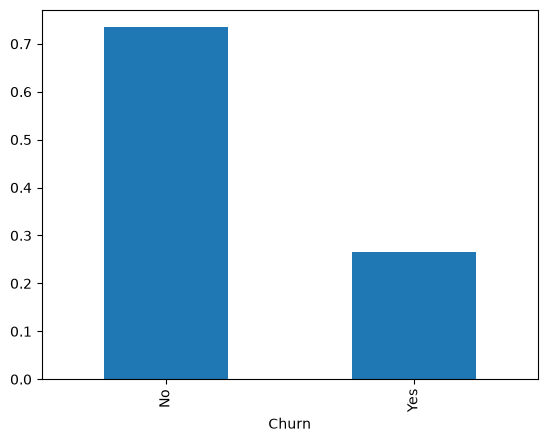

In [59]:
data['Churn'].value_counts(normalize=True).plot.bar()

In [60]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [61]:
data['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [62]:
# check any duplicate rows are present in the dataset
data.duplicated().sum()

np.int64(0)

In [63]:
# check categroical columns in the dataset
data.select_dtypes(include='object').columns

C:\Users\user\AppData\Local\Temp\ipykernel_24028\1044801771.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object').columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [64]:
# check numerical columns in the dataset
data.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [65]:
# i don't need customerID column so i will drop it
data.drop('customerID', axis=1, inplace=True)

In [66]:
data.shape

(7043, 20)

In [67]:
# investigate TotalCharges column
data["TotalCharges"].value_counts().head(20)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64

In [68]:
data.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [69]:
data['TotalCharges'].isnull().sum()

np.int64(0)

In [70]:
data[data['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [71]:
data["TotalCharges"].isnull().sum()

np.int64(0)

In [72]:
# step3 --> separate the features and target variable
X =data.drop("Churn",axis=1)
y= data["Churn"]

In [73]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [74]:
# Svm supports only numerical values so convert target data into 0 & 1
y = y.map({"No":0,"Yes":1})

In [75]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [76]:
# Identify categorical columns in the dataset
categorical_columns = X.select_dtypes(include=['object']).columns.to_list()
print("Categorical columns:", categorical_columns)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


C:\Users\user\AppData\Local\Temp\ipykernel_24028\2724185909.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=['object']).columns.to_list()


In [77]:
# identify numeircal columns
numerical_columns = X.select_dtypes(include=["int64","float64"]).columns.tolist()
print("Numerical columns:", numerical_columns)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [78]:
# Build the preprocessing pipeline for categorical and numerical features
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer


In [79]:
proprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(), categorical_columns)
    ]
)

In [80]:
X.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [81]:
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"], errors="coerce"
).fillna(0)

In [82]:
X =  data.drop(columns=["Churn"])

In [83]:
X.isnull().sum().sort_values(ascending=False)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

In [84]:
X[X.isnull().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges


In [85]:
data["TotalCharges"]=data["TotalCharges"].fillna(0)

In [86]:
X = data.drop("Churn",axis=1)

In [87]:
print("Missing values by column:")
print(X.isnull().sum())

Missing values by column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [93]:
# Recreate feature lists and the preprocessing pipeline after handling missing values
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()
print("Categorical columns:", categorical_columns)
print("Numerical columns:", numerical_columns)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(), categorical_columns)
    ]
)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\user\AppData\Local\Temp\ipykernel_24028\3866185666.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()


In [94]:
# split the dataset into training and testing dataset
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [91]:
print("X_train:", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train: (5634, 19)
X_test (1409, 19)
y_train (5634,)
y_test (1409,)


In [95]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,precision_score,recall_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)

In [ ]:
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("classification_report:\n", classification_report(y_test, y_pred))
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))

accuracy_score: 0.8055358410220014
f1_score 0.6040462427745664
classification_report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

precision_score: 0.6572327044025157
recall_score: 0.5588235294117647


In [ ]:
print("confusion_matrix", confusion_matrix(y_test, y_pred))

confusion_matrix [[926 109]
 [165 209]]


In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [98]:
print("Random Forest Classifier Results:")
print("accuracy_score:" , accuracy_score(y_test, y_pred_rf))
print("f1_score", f1_score(y_test, y_pred_rf))
print("classification_report:\n", classification_report(y_test, y_pred_rf))
print("precision_score:", precision_score(y_test, y_pred_rf))
print("recall_score:", recall_score(y_test, y_pred_rf))

print("confusion_matrix", confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Results:
accuracy_score: 0.7835344215755855
f1_score 0.5413533834586466
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

precision_score: 0.6185567010309279
recall_score: 0.48128342245989303
confusion_matrix [[924 111]
 [194 180]]


In [99]:
# Linear SVM
from sklearn.svm import SVC

svm_linear_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",SVC(kernel="linear"))
])

svm_linear_pipeline.fit(X_train,y_train)

y_pred_linear_svm =svm_linear_pipeline.predict(X_test)


In [102]:
print("Linear SVM Linear Kernel Results:")
print("accuracy_score:" , accuracy_score(y_test, y_pred_linear_svm ))
print("f1_score", f1_score(y_test, y_pred_linear_svm ))
print("classification_report:\n", classification_report(y_test, y_pred_linear_svm ))
print("precision_score:", precision_score(y_test, y_pred_linear_svm ))
print("recall_score:", recall_score(y_test, y_pred_linear_svm ))

print("confusion_matrix", confusion_matrix(y_test, y_pred_linear_svm ))

Linear SVM Linear Kernel Results:
accuracy_score: 0.7877927608232789
f1_score 0.5685425685425686
classification_report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

precision_score: 0.6175548589341693
recall_score: 0.5267379679144385
confusion_matrix [[913 122]
 [177 197]]


In [101]:
# Now let's try SVM with RBF kernel

svm_rbf_kernel = Pipeline([
    ("preprocessor",preprocessor),
    ("model", SVC(kernel="rbf"))
])

svm_rbf_kernel.fit(X_train,y_train)

svm_rbf_pred = svm_rbf_kernel.predict(X_test)

In [103]:
print("Linear SVM rbf kernel Results:")
print("accuracy_score:" , accuracy_score(y_test, svm_rbf_pred))
print("f1_score", f1_score(y_test, svm_rbf_pred ))
print("classification_report:\n", classification_report(y_test, svm_rbf_pred ))
print("precision_score:", precision_score(y_test, svm_rbf_pred ))
print("recall_score:", recall_score(y_test, svm_rbf_pred ))

print("confusion_matrix", confusion_matrix(y_test, svm_rbf_pred ))

Linear SVM rbf kernel Results:
accuracy_score: 0.7913413768630234
f1_score 0.551829268292683
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

precision_score: 0.6418439716312057
recall_score: 0.4839572192513369
confusion_matrix [[934 101]
 [193 181]]


In [104]:
  # Now let's try with C
c = [0.01,0.1,1,10,100]

for c in c:
    svm_rbf_kernel = Pipeline([
        ("preprocessor",preprocessor),
        ("model", SVC(kernel="rbf", C=c))
    ])
    
    svm_rbf_kernel.fit(X_train,y_train)
    
    svm_rbf_pred = svm_rbf_kernel.predict(X_test)
    
    print(f"Results for C={c}:")
    print("accuracy_score:" , accuracy_score(y_test, svm_rbf_pred))
    print("f1_score", f1_score(y_test, svm_rbf_pred ))
    print("classification_report:\n", classification_report(y_test, svm_rbf_pred ))
    print("precision_score:", precision_score(y_test, svm_rbf_pred ))
    print("recall_score:", recall_score(y_test, svm_rbf_pred ))
    
    print("confusion_matrix", confusion_matrix(y_test, svm_rbf_pred ))

Results for C=0.01:
accuracy_score: 0.7345635202271115
f1_score 0.0
classification_report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

precision_score: 0.0
recall_score: 0.0
confusion_matrix [[1035    0]
 [ 374    0]]


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Results for C=0.1:
accuracy_score: 0.7920511000709723
f1_score 0.5296950240770465
classification_report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      1035
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

precision_score: 0.6626506024096386
recall_score: 0.4411764705882353
confusion_matrix [[951  84]
 [209 165]]
Results for C=1:
accuracy_score: 0.7913413768630234
f1_score 0.551829268292683
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

precision_score: 0.641843971

In [105]:
# gamma 
gamma_values = ["scale","auto",0.01,0.1,1,10]

for gamma in gamma_values:
    svm = Pipeline([
        ("preprocessor",preprocessor),
        ("model", SVC(kernel="rbf", gamma=gamma,C=1))
    ])

    svm.fit(X_train,y_train)
    y_pred = svm.predict(X_test)

    print(f"Results for gamma={gamma}:")
    print("accuracy_score:" , accuracy_score(y_test, y_pred))
    print("f1_score", f1_score(y_test, y_pred ))
    print("classification_report:\n", classification_report(y_test, y_pred ))
    print("precision_score:", precision_score(y_test, y_pred ))
    print("recall_score:", recall_score(y_test, y_pred ))
    print("confusion_matrix", confusion_matrix(y_test, y_pred ))

Results for gamma=scale:
accuracy_score: 0.7913413768630234
f1_score 0.551829268292683
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

precision_score: 0.6418439716312057
recall_score: 0.4839572192513369
confusion_matrix [[934 101]
 [193 181]]
Results for gamma=auto:
accuracy_score: 0.794889992902768
f1_score 0.5463108320251178
classification_report:
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

precision_score:

In [106]:
 # create a 2D visualization 
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit the existing preprocessing only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if required
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# Reduce to 2 dimensions only for visualization
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print("Original features:", X_train_processed.shape[1])
print("PCA features:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_)

Original features: 45
PCA features: 2
Explained variance: [0.27320009 0.17971525]


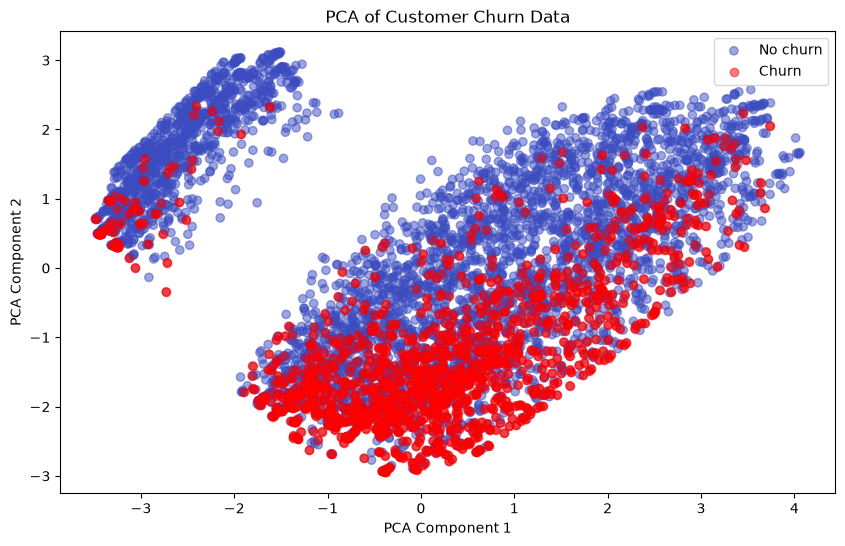

In [ ]:
#Step2 First visualize the actual customers

plt.figure(figsize=(10, 6))

plt.scatter(X_train_pca[0, 0], X_train_pca[0, 1], label='No churn', c=y_train, cmap='coolwarm', alpha=0.5)

plt.scatter(X_train_pca[y_train==1, 0], X_train_pca[y_train==1, 1], label='Churn', c='red', alpha=0.5)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Customer Churn Data')
plt.legend()
plt.show()

In [108]:
# Step3 Visulaize Logoistic Regression Model Predictions

from sklearn.linear_model import LogisticRegression

lr_visual = LogisticRegression()
lr_visual.fit(X_train_pca, y_train)





,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [109]:
# Now create a decision_boundary graph

from matplotlib.colors import ListedColormap
def plot_decision_boundary(model, X, y, title):
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary and data points
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('blue', 'red')))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o', cmap=ListedColormap(('blue', 'red')))
    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.show()

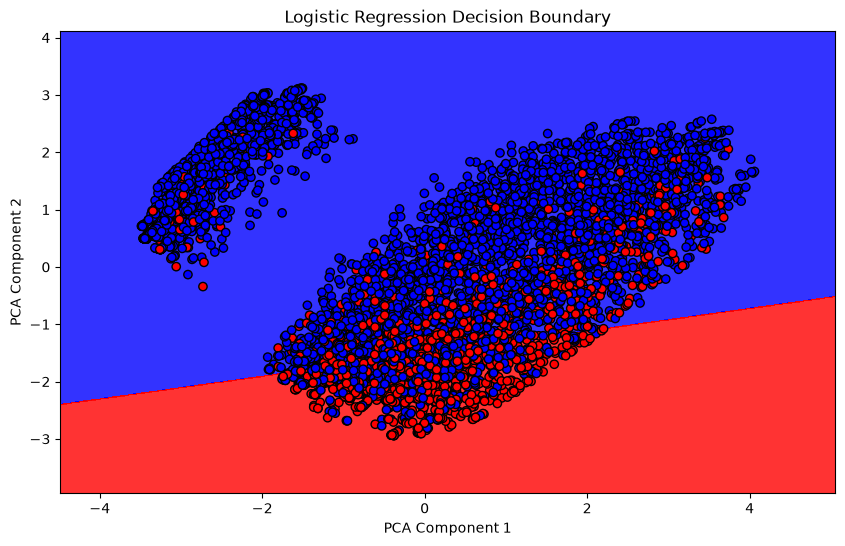

In [110]:
plot_decision_boundary(
    lr_visual,
    X_train_pca,
    y_train,
    "Logistic Regression Decision Boundary"
)

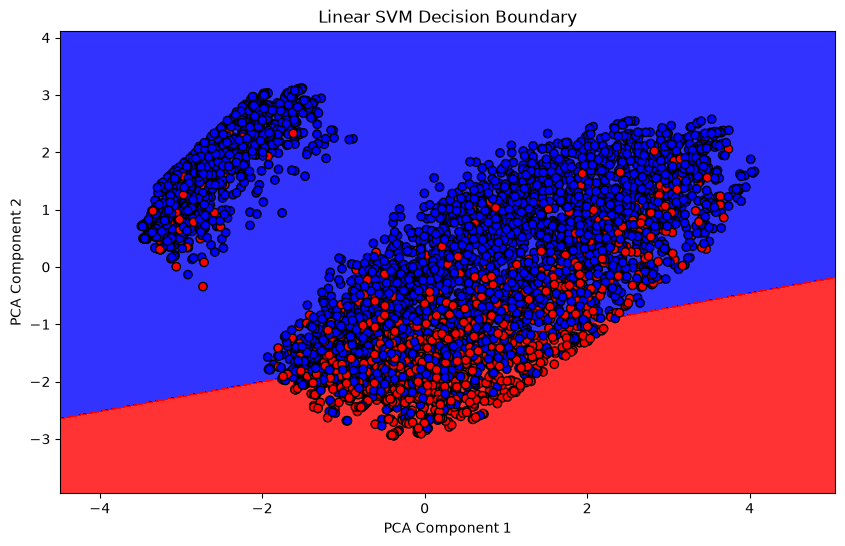

In [111]:
# now visualize Linear SVM
from sklearn.svm import SVC

linear_svm = SVC(kernel="linear")
linear_svm.fit(X_train_pca, y_train)

plot_decision_boundary(
    linear_svm,X_train_pca,y_train,"Linear SVM Decision Boundary"
)

In [112]:
# svm has support vectors 
print("Number of support vectors for each class:", linear_svm.n_support_)

print("Total support vectors:", sum(linear_svm.n_support_))

Number of support vectors for each class: [1449 1448]
Total support vectors: 2897


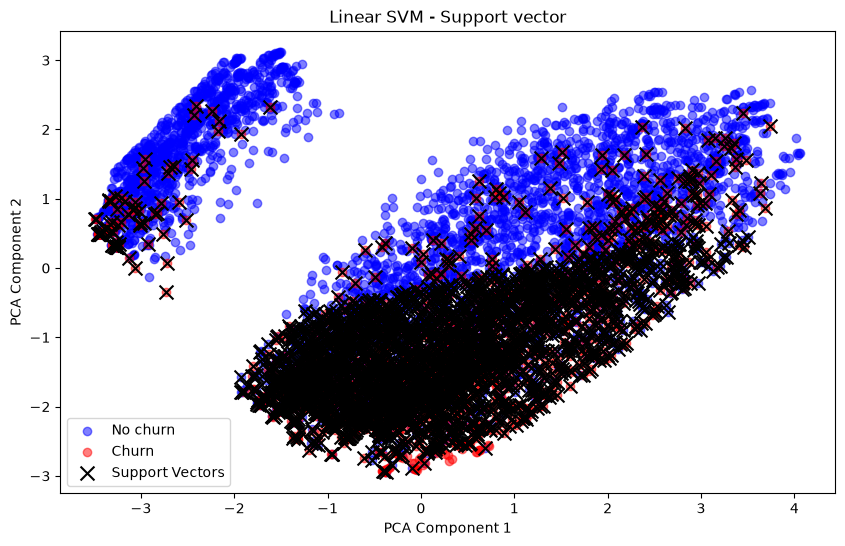

In [114]:
# now visulaize that 

plt.figure(figsize=(10, 6))

plt.scatter(X_train_pca[y_train==0,0], X_train_pca[y_train==0,1], label='No churn', c='blue', alpha=0.5)

plt.scatter(X_train_pca[y_train==1,0], X_train_pca[y_train==1,1], label='Churn', c='red', alpha=0.5)

support_vectors = linear_svm.support_vectors_
plt.scatter(support_vectors[:,0], support_vectors[:,1], label='Support Vectors', c='black', marker='x', s=100)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Linear SVM - Support vector")
plt.legend()
plt.show()


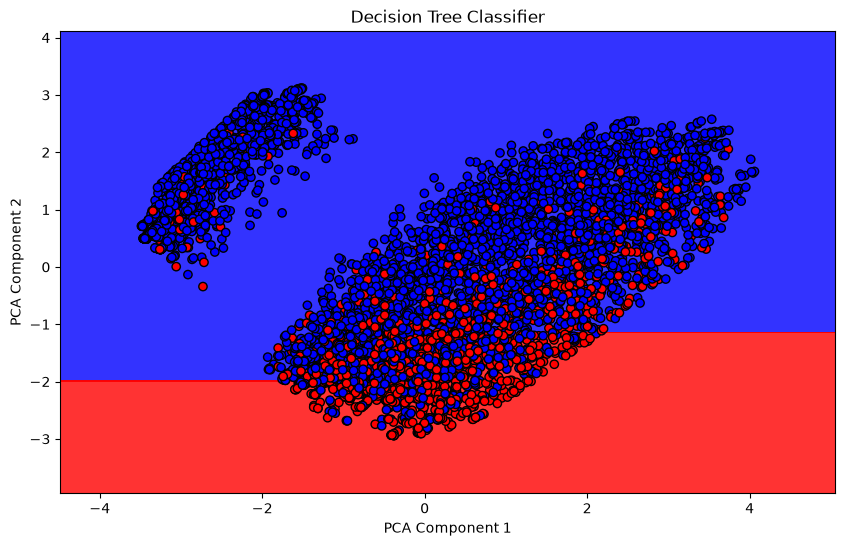

In [116]:
# visualize decisoon tree
from sklearn.tree import DecisionTreeClassifier
decision_visualize = DecisionTreeClassifier(max_depth=4,random_state=42)

decision_visualize.fit(X_train_pca,y_train)

decision_visualize.fit(X_train_pca,y_train)

plot_decision_boundary(decision_visualize,X_train_pca,y_train,"Decision Tree Classifier")

In [117]:
# Define search space

param_distributions ={
    "model__kernel": ["linear","rbf"],
    "model__c": [0.01,01.1,10,100],
    "model__gamma":["scale","auto", 0.001, 0.01, 0.1, 1]
}

In [118]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

param_distributions = {
    "model__kernel": ["linear", "rbf"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1]
}

random_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...del', SVC())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': [0.01, 0.1, ...], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_ind

In [119]:
print("Best parameters:",random_search.best_params_)
print("Best F1-Score:", random_search.best_score_)

Best parameters: {'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.01}
Best F1-Score: 0.5901522166834973


In [120]:
best_svm = random_search.best_estimator_
y_pred = best_svm.predict(X_test)

In [122]:
from sklearn.metrics import (accuracy_score,classification_report,precision_score,recall_score,f1_score,confusion_matrix)

print("accuracy:",accuracy_score(y_test,y_pred))
print("precision:", precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("classification_report:",classification_report(y_test,y_pred))

print("confusion matrix:",confusion_matrix(y_test,y_pred))

accuracy: 0.794180269694819
precision: 0.6329113924050633
recall: 0.5347593582887701
f1: 0.5797101449275363
classification_report:               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

confusion matrix: [[919 116]
 [174 200]]


In [123]:
print(random_search.best_params_)
print(random_search.best_score_)

{'model__kernel': 'linear', 'model__gamma': 'scale', 'model__C': 0.01}
0.5901522166834973


In [124]:
results = random_search.cv_results_
print(results["mean_test_score"])

[0.59015222 0.         0.58110341 0.56097302 0.53999517 0.58110601
 0.57361579 0.58110601 0.58785236 0.51665546 0.58110341 0.58110601
 0.5675582  0.         0.58110601]
